# 시각화 기법
## X축 tick label 다루기

시계열 그래프는 x축 시간을 설정 > 변화하는 변수를 설정하는 차트

- 시계열 그래프의 x축 라벨 설정
- 데이터셋 : ABNB_stock.csv

In [11]:
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [3]:
df_abnb = pd.read_csv('./data/ABNB_stock.csv')
df_abnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       454 non-null    object 
 1   Open       454 non-null    float64
 2   High       454 non-null    float64
 3   Low        454 non-null    float64
 4   Close      454 non-null    float64
 5   Adj Close  454 non-null    float64
 6   Volume     454 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 25.0+ KB


<Axes: xlabel='Date', ylabel='Close'>

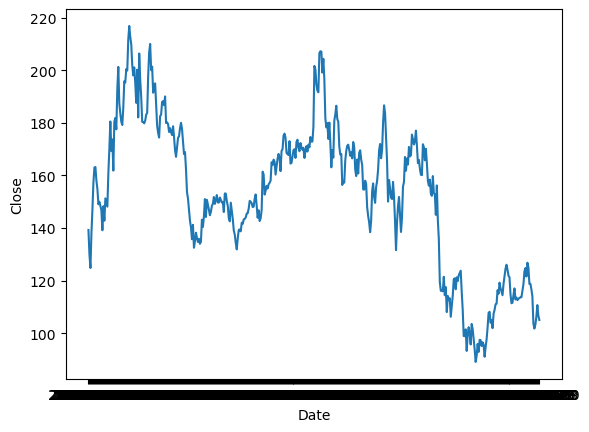

In [6]:
fig, ax = plt.subplots()
sns.lineplot(data=df_abnb, x='Date', y='Close', ax=ax)

In [7]:
# datetime type으로 변환
df_abnb['Date'] =  pd.to_datetime(df_abnb['Date'])
df_abnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       454 non-null    datetime64[ns]
 1   Open       454 non-null    float64       
 2   High       454 non-null    float64       
 3   Low        454 non-null    float64       
 4   Close      454 non-null    float64       
 5   Adj Close  454 non-null    float64       
 6   Volume     454 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 25.0 KB


<Axes: xlabel='Date', ylabel='Close'>

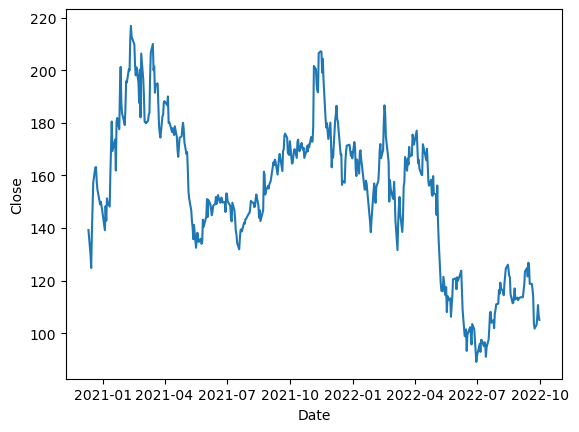

In [8]:
fig, ax = plt.subplots()
sns.lineplot(data=df_abnb, x='Date', y='Close', ax=ax)

In [ ]:
# 축레이블 회전, 표현방식을 변경 > formatter를 사용

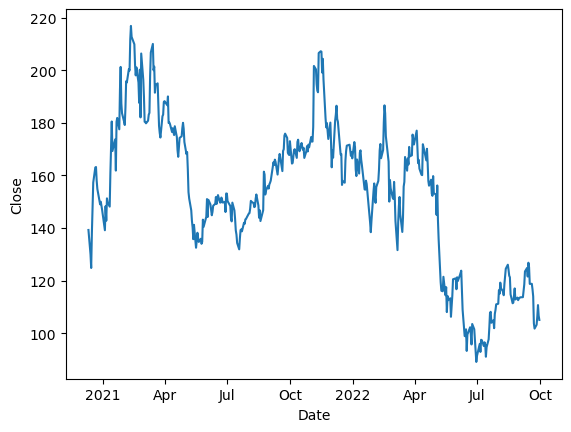

In [10]:
import matplotlib as mpl

fig, ax = plt.subplots()
sns.lineplot(data=df_abnb, x='Date', y='Close', ax=ax)
ax.xaxis.set_major_formatter(mpl.dates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

In [ ]:
# plotly line

In [14]:
px.line(data_frame=df_abnb, x='Date', y='Close'
        ,width=500, height=400)

In [17]:
fig = px.line(data_frame=df_abnb, x='Date', y='Close'
        ,width=500, height=400)
fig.update_xaxes(tickformat='%Y-%m-%d')

# 다중 축 차트

기본 차트 x,y + y1, y2 -> 하나의 ax에 그리기

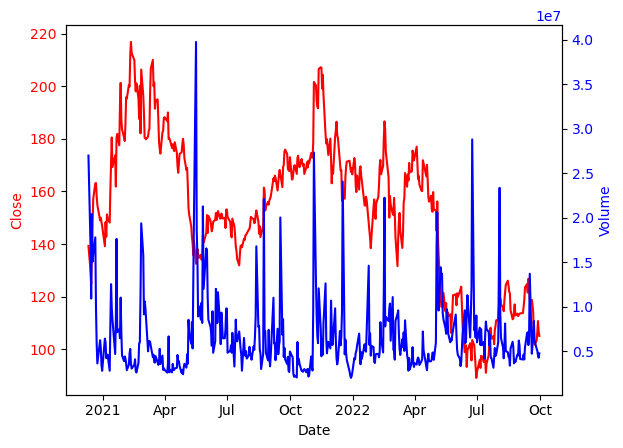

In [28]:
fig, ax = plt.subplots()
ax2 = ax.twinx()

sns.lineplot(x='Date',y='Close',data=df_abnb, ax=ax, color='red')
sns.lineplot(x='Date',y='Volume',data=df_abnb, ax=ax2, color='blue')

#왼쪽 y축 정보 설정
ax.tick_params(axis='y',labelcolor='red')
ax.yaxis.label.set_color('red')
#오른쪽 y축 정보 설정
ax2.tick_params(axis='y',labelcolor='blue')
ax2.yaxis.label.set_color('blue')

ax.xaxis.set_major_formatter(mpl.dates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

In [29]:
# 3개 축
# 최고가 - 최저가 = HighLow 변수
df_abnb['High-Low'] = df_abnb['High'] - df_abnb['Low']
df_abnb.head()

,Date,Open,High,Low,Close,Adj Close,Volume,High-Low
0,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800,16.399994
1,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100,10.139999
2,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400,6.099998
3,2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600,17.089996
4,2020-12-17,143.000000,152.449997,142.669998,147.050003,147.050003,15054700,9.779999


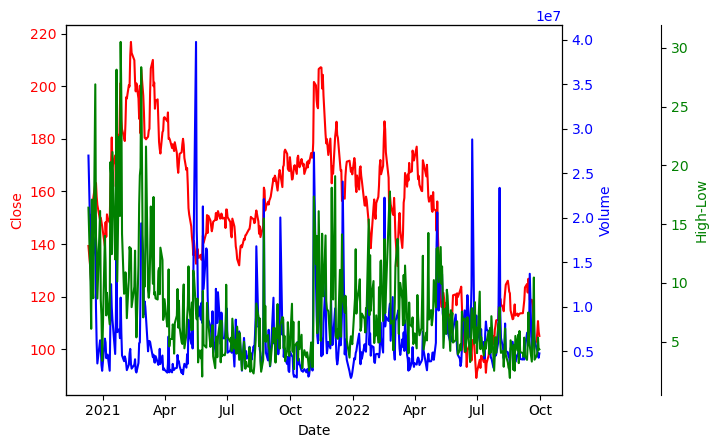

In [ ]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax3 = ax.twinx()

ax3.spines.right.set_position(('axes',1.2)) #현재축 위치 1에서 0.2만큼 오른쪽으로 이동

sns.lineplot(x='Date',y='Close',data=df_abnb, ax=ax, color='red')
sns.lineplot(x='Date',y='Volume',data=df_abnb, ax=ax2, color='blue')
sns.lineplot(x='Date',y='High-Low',data=df_abnb, ax=ax3, color='green')

#왼쪽 y축 정보 설정
ax.tick_params(axis='y',labelcolor='red')
ax.yaxis.label.set_color('red')
#오른쪽 y축 정보 설정
ax2.tick_params(axis='y',labelcolor='blue')
ax2.yaxis.label.set_color('blue')
ax3.tick_params(axis='y',labelcolor='green')
ax3.yaxis.label.set_color('green')

ax.xaxis.set_major_formatter(mpl.dates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

In [49]:
#plotly로 2중축 차트
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{'secondary_y': True}]]) #2dimension list로 spec 지정

#축설정
sub_fig_1 = px.line(data_frame=df_abnb, x='Date',y='Close')
sub_fig_1.update_traces(line_color='red')
sub_fig_2 = px.line(data_frame=df_abnb, x='Date',y='Volume')
sub_fig_2.update_traces(line_color='blue')
sub_fig_2.update_traces(yaxis='y2')

fig.add_traces(sub_fig_1.data + sub_fig_2.data)

#레이블설정
fig.layout.xaxis.title = 'Date'
fig.layout.yaxis.title = 'Close'
fig.layout.yaxis.color = 'red'
fig.layout.yaxis2.title = 'Volume'
fig.layout.yaxis2.color = 'blue'

fig.update_layout(width=500, height=400)

In [ ]:
# plotly.graph_object
# 3개 축 그리기

In [92]:
import plotly.graph_objects as go
fig = make_subplots()
fig.add_trace(
    go.Scatter(
        x=df_abnb['Date'], y=df_abnb['Close']
        ,name = 'Close', mode='lines'
        ,yaxis='y', line={'color':'red'}
    ) #1번째 축
)
fig.add_trace(
    go.Scatter(
        x=df_abnb['Date'], y=df_abnb['Volume']
        ,name = 'Volume', mode='lines'
        ,yaxis='y2', line={'color':'blue'}
    ) #2번째 축
)
fig.add_trace(
    go.Scatter(
    x=df_abnb['Date'], y=df_abnb['High-Low']
    ,name = 'High-Low', mode='lines'
    ,yaxis='y3', line={'color':'green'}    
    ) #3번째 축
)

fig.update_layout(
    yaxis = dict(title='Close'),
    yaxis2 = dict(title='Volume', side='right', overlaying='y', anchor='free', position=1),
    yaxis3 = dict(title='High-Low', side='right', overlaying='y', anchor='x'),
    xaxis = dict(title='Date', domain=[.1, .85]),
    width=600, height=400
)
fig.layout.yaxis.color = 'red'
fig.layout.yaxis2.color = 'blue'
fig.layout.yaxis3.color = 'green'

fig.show()

# 범례 위치 조정하기

In [93]:
df_co2 = pd.read_csv('./data/CO2_Emissions.csv')
df_co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

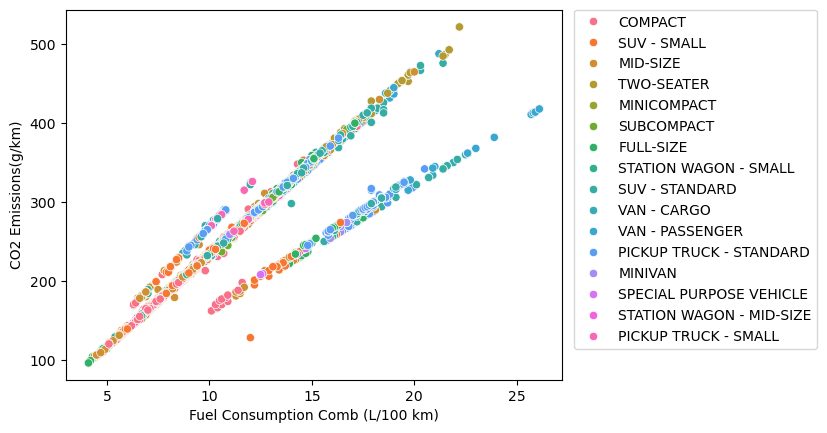

In [106]:
fig, ax = plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2, hue='Vehicle Class',
    ax=ax
)
ax.legend(bbox_to_anchor=(1.01, 1.02)) #왼쪽 하단 0.0, 오른쪽 상단 1.1

In [123]:
fig = px.scatter(
    data_frame=df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    color='Vehicle Class'
)
fig.update_layout(legend_x=1.0, legend_y=1.0)
fig.show()

# 강조하기
테두리 색, 굵기 조정

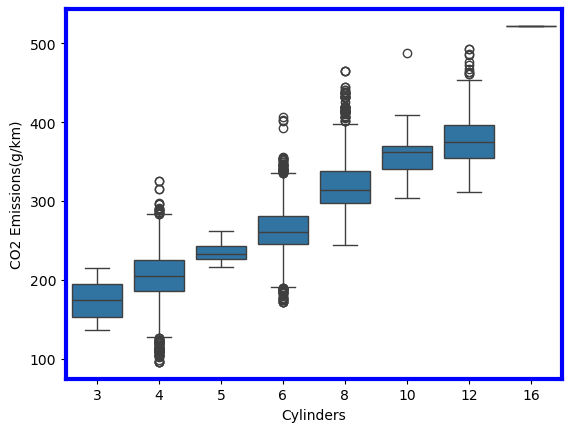

In [126]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df_co2, x='Cylinders',
    y='CO2 Emissions(g/km)', ax=ax
)
spines = ['left', 'right', 'top', 'bottom']
for spin in spines:
    ax.spines[spin].set_color('blue')
    ax.spines[spin].set_linewidth(3)

In [134]:
# plotly 테두리 강조하기
fig = px.box(data_frame=df_co2, x='Cylinders',
    y='CO2 Emissions(g/km)'
)
fig.update_xaxes(showline=True, linecolor='black', linewidth=3, mirror=True)
fig.update_yaxes(showline=True, linecolor='black', linewidth=3, mirror=True)
fig.show()

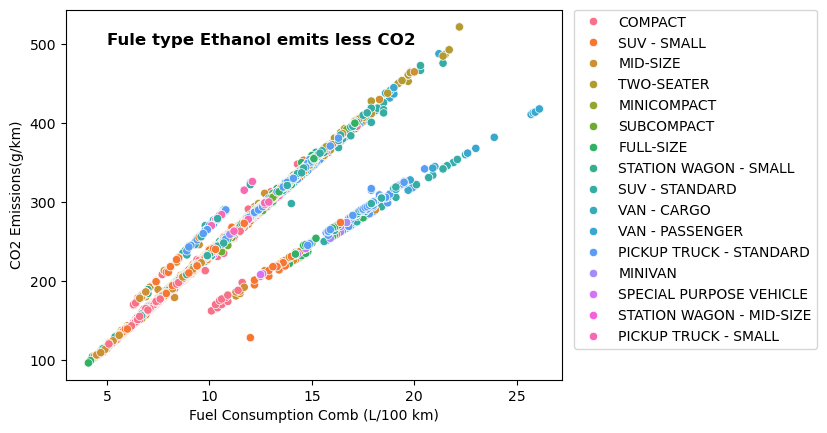

In [156]:
# 텍스트, annotate()로 표시하기
fig, ax = plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2, hue='Vehicle Class',
    ax=ax
)
ax.text(
    x=5,y=500, #절대좌표
    s='Fule type Ethanol emits less CO2',
    fontdict={'fontsize':12, 'weight':'bold'}
)
ax.legend(bbox_to_anchor=(1.01, 1.02)) #왼쪽 하단 0.0, 오른쪽 상단 1.1

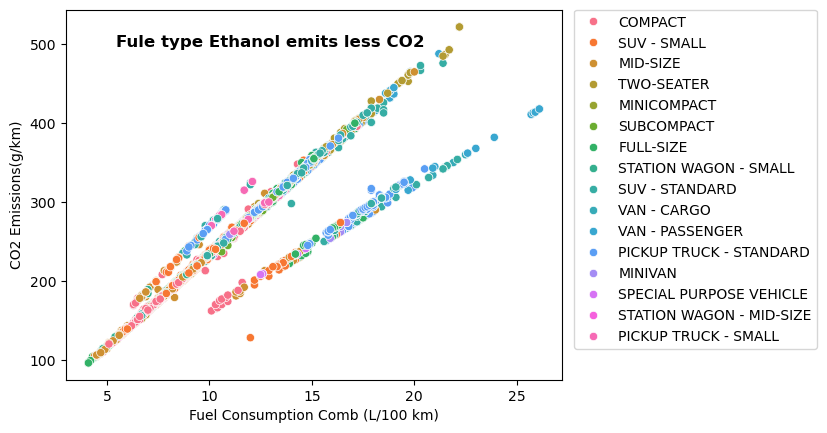

In [157]:
# 텍스트, annotate()로 표시하기
fig, ax = plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2, hue='Vehicle Class',
    ax=ax
)
ax.text(
    x=0.1,y=0.9, #상대좌표
    s='Fule type Ethanol emits less CO2',
    fontdict={'fontsize':12, 'weight':'bold'},
    transform=ax.transAxes # 상대좌표를 전달
)
ax.legend(bbox_to_anchor=(1.01, 1.02)) #왼쪽 하단 0.0, 오른쪽 상단 1.1

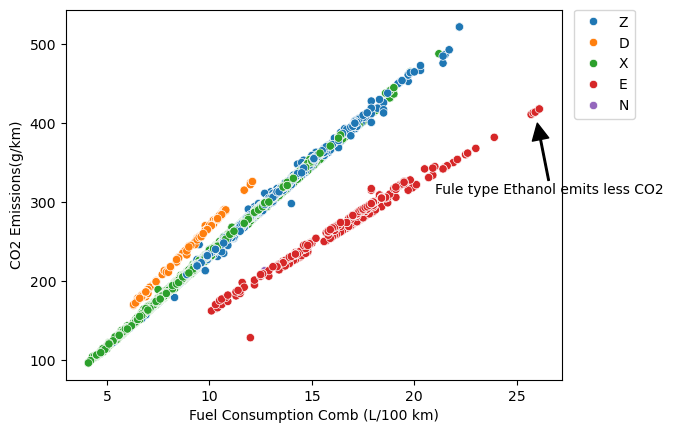

In [158]:
# annotate()로 표시하기
fig, ax = plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2, hue='Fuel Type',
    ax=ax
)
ax.annotate(
    xy = (26,400), #화살표 절대좌표
    text ='Fule type Ethanol emits less CO2',
    xytext = (21,310), #텍스트의 좌표
    arrowprops={'color':'black', 'width':1.1}
)
ax.legend(bbox_to_anchor=(1.01, 1.02)) #왼쪽 하단 0.0, 오른쪽 상단 1.1

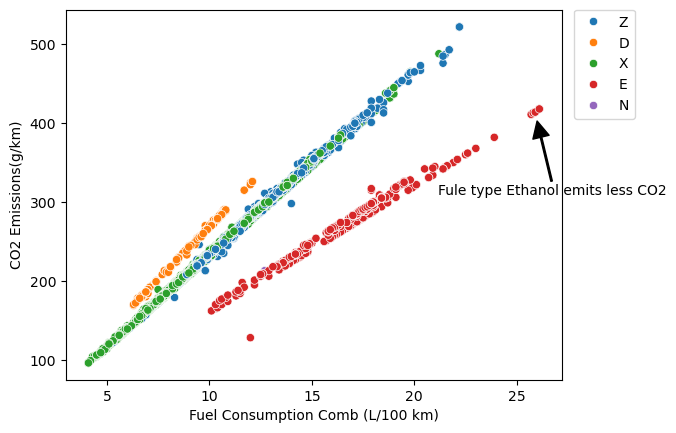

In [159]:
# annotate()로 표시하기
fig, ax = plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2, hue='Fuel Type',
    ax=ax
)
ax.annotate(
    xy = (0.95,0.7), #화살표 상대좌표
    text ='Fule type Ethanol emits less CO2',
    xytext = (0.75,0.5), #텍스트의 좌표
    arrowprops={'color':'black', 'width':1.1},
    xycoords=ax.transAxes #상대좌표
)
ax.legend(bbox_to_anchor=(1.01, 1.02)) #왼쪽 하단 0.0, 오른쪽 상단 1.1

In [ ]:
#plotly
fig = px.scatter(
    data_frame=df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    color='Fuel Type'
)
fig.add_annotation(
    x=0.93, y=0.75, #상대좌표
    text='<b>Fule type Ethanol emits less CO2',
    showarrow=True, arrowhead=2,
    yref='y domain', xref='x domain'
)
fig.show()

# 조건을 이용한 강조하기

In [173]:
df_ins = pd.read_csv('./data/product_inspection.csv')
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             429 non-null    object 
 1   inspection_step  429 non-null    object 
 2   value            429 non-null    float64
 3   upper_spec       429 non-null    float64
 4   target           429 non-null    float64
 5   lower_spec       429 non-null    float64
dtypes: float64(4), object(2)
memory usage: 20.2+ KB


In [174]:
df_ins['date'] =  pd.to_datetime(df_ins['date'])
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             429 non-null    datetime64[ns]
 1   inspection_step  429 non-null    object        
 2   value            429 non-null    float64       
 3   upper_spec       429 non-null    float64       
 4   target           429 non-null    float64       
 5   lower_spec       429 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 20.2+ KB


In [ ]:
df_ins_A = df_ins.query("inspection_step=='A'") #검사공정 == A
df_ins_A

,date,inspection_step,value,upper_spec,target,lower_spec
0,2022-01-01,A,21.2,22.0,21.3,20.6
1,2022-01-02,A,21.7,22.0,21.3,20.6
2,2022-01-03,A,21.4,22.0,21.3,20.6
3,2022-01-04,A,21.5,22.0,21.3,20.6
4,2022-01-05,A,21.5,22.0,21.3,20.6
...,...,...,...,...,...,...
138,2022-05-19,A,21.7,22.0,21.3,20.6
139,2022-05-20,A,21.6,22.0,21.3,20.6
140,2022-05-21,A,21.6,22.0,21.3,20.6
141,2022-05-22,A,21.4,22.0,21.3,20.6


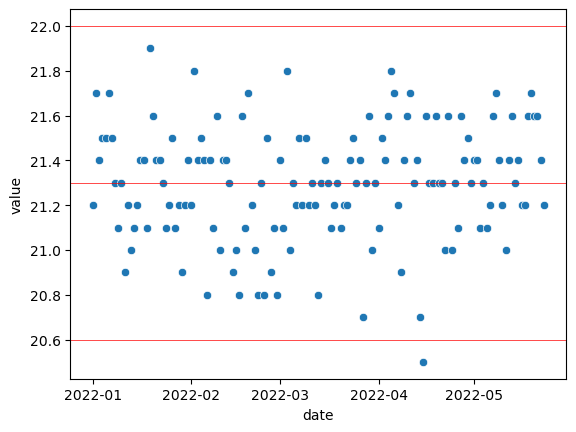

In [180]:
fig,ax = plt.subplots()
sns.scatterplot(
    x='date', y='value', data=df_ins_A, ax=ax
)
#수평선 그리기
ax.axhline(df_ins_A['lower_spec'].iloc[-1], color='red', linewidth=0.5)
ax.axhline(df_ins_A['upper_spec'].iloc[-1], color='red', linewidth=0.5)
ax.axhline(df_ins_A['target'].iloc[-1], color='red', linewidth=0.5)

In [182]:
#plotly
fig = px.scatter(data_frame=df_ins_A, x='date', y='value', width=500, height=400)
fig.add_hline(df_ins_A['lower_spec'].iloc[-1], line_color='red', line_width=0.5)
fig.add_hline(df_ins_A['upper_spec'].iloc[-1], line_color='red', line_width=0.5)
fig.add_hline(df_ins_A['target'].iloc[-1], line_color='red', line_width=0.5)

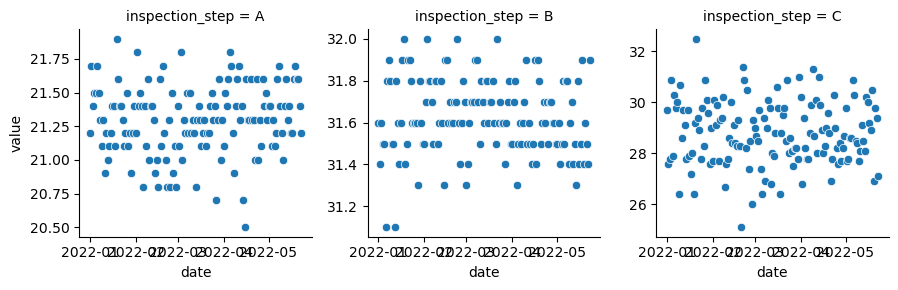

In [ ]:
g = sns.FacetGrid(df_ins,sharex=False,sharey=False,col='inspection_step') # 검사공정 값 A,B,C 각각 차트 구분
g.map_dataframe(sns.scatterplot,x='date',y='value')

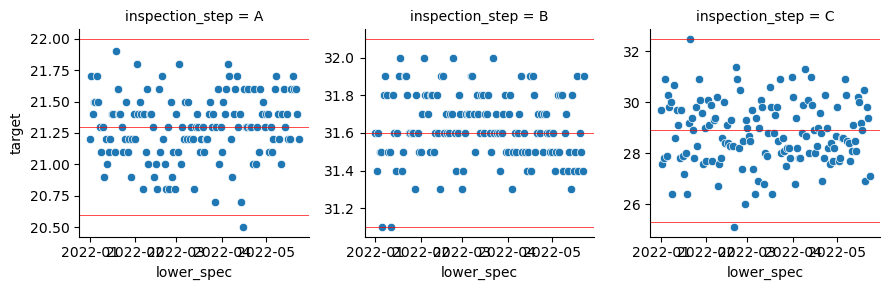

In [ ]:
#facetgrid.map() 함수를 위한 커스텀 함수 정의
def custom(lower_spec, target, upper_spec, **kws):
    ax = plt.gca()
    ax.axhline(lower_spec.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(target.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(upper_spec.iloc[-1], color='red', linewidth=0.5)
    
g = sns.FacetGrid(df_ins,sharex=False,sharey=False,col='inspection_step') # 검사공정 값 A,B,C 각각 차트 구분
g.map_dataframe(sns.scatterplot,x='date',y='value')
g.map(custom, 'lower_spec', 'target', 'upper_spec')

In [ ]:
# For 문을 이용한 plotly에서의 facet mapping
fig = px.scatter(df_ins, x='date', y='value', facet_col='inspection_step', facet_col_spacing=0.05)

for idx in range(df_ins['inspection_step'].nunique()):
    step = fig.layout.annotations[idx].text.split('=')[1]
    fig.add_hline(
        y=df_ins.query('inspection_step == @step')['lower_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df_ins.query('inspection_step == @step')['upper_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df_ins.query('inspection_step == @step')['target'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
        
    
fig.update_yaxes(matches=None)
fig.update_yaxes(showticklabels=True)
fig.show()

In [194]:
#특정 조건에 해당하는 값 찾기
#각 공정별로 관리스펙에서 벗어난 자재가 있는 그래프 테두리 강조
df_ins['spec_out'] = (df_ins['value'] > df_ins['upper_spec']) | (df_ins['value'] < df_ins['lower_spec'])
df_ins.head()

,date,inspection_step,value,upper_spec,target,lower_spec,spec_out
0,2022-01-01,A,21.2,22.0,21.3,20.6,False
1,2022-01-02,A,21.7,22.0,21.3,20.6,False
2,2022-01-03,A,21.4,22.0,21.3,20.6,False
3,2022-01-04,A,21.5,22.0,21.3,20.6,False
4,2022-01-05,A,21.5,22.0,21.3,20.6,False


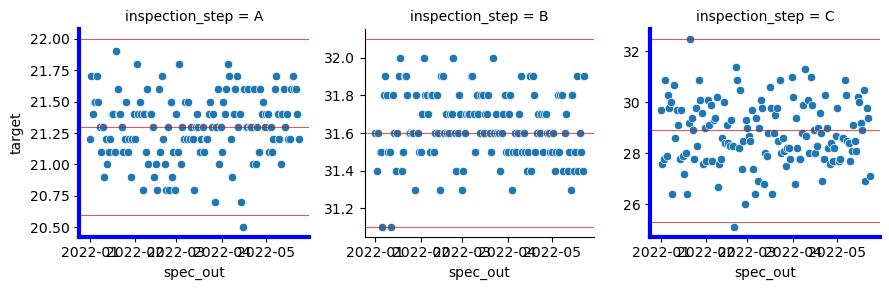

In [205]:
#facetgrid.map() 함수를 위한 커스텀 함수 정의
def custom(lower_spec, target, upper_spec, **kws):
    ax = plt.gca()
    ax.axhline(lower_spec.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(target.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(upper_spec.iloc[-1], color='red', linewidth=0.5)


def if_spec_out(spec_out, **kws):
    if spec_out.sum() > 0:
        ax=plt.gca()
        spines=['left', 'bottom']
        for spine in spines:
            ax.spines[spine].set_color('blue')
            ax.spines[spine].set_linewidth(3)
    
g = sns.FacetGrid(df_ins,sharex=False,sharey=False,col='inspection_step') # 검사공정 값 A,B,C 각각 차트 구분
g.map_dataframe(sns.scatterplot,x='date',y='value')
g.map(custom, 'lower_spec', 'target', 'upper_spec')
g.map(if_spec_out, 'spec_out')



In [216]:
# For 문을 이용한 plotly에서의 facet mapping
fig = px.scatter(df_ins, x='date', y='value', facet_col='inspection_step', facet_col_spacing=0.05)

for idx in range(df_ins['inspection_step'].nunique()):
    step = fig.layout.annotations[idx].text.split('=')[1]
    fig.add_hline(
        y=df_ins.query('inspection_step == @step')['lower_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df_ins.query('inspection_step == @step')['upper_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df_ins.query('inspection_step == @step')['target'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    if df_ins.query('inspection_step == @step')['spec_out'].sum() > 0:
        fig.update_xaxes(showline=True, linecolor='black', linewidth=3, row=1, col=idx+1)
        fig.update_yaxes(showline=True, linecolor='black', linewidth=3, row=1, col=idx+1)
    
fig.update_yaxes(matches=None)
fig.update_yaxes(showticklabels=True)
fig.show()

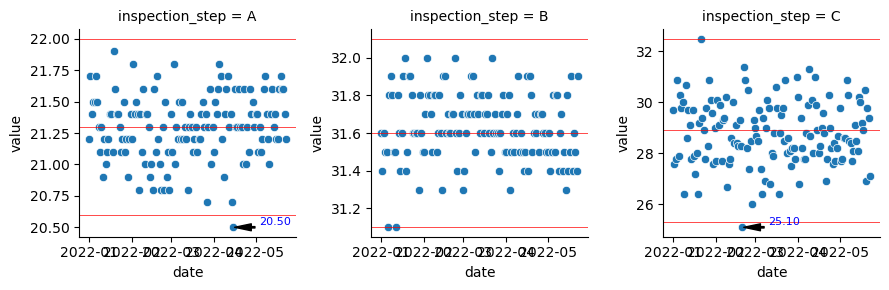

In [214]:
def custom_plot_with_annotations(data, **kws):
    ax = plt.gca()
    
    # 산점도 그리기
    sns.scatterplot(x='date', y='value', data=data, ax=ax)
    
    # spec 라인 그리기
    if not data.empty:
        ax.axhline(data['lower_spec'].iloc[-1], color='red', linewidth=0.5)
        ax.axhline(data['target'].iloc[-1], color='red', linewidth=0.5)
        ax.axhline(data['upper_spec'].iloc[-1], color='red', linewidth=0.5)
    
    # spec에서 벗어난 값에 annotation과 화살표 추가
    outliers = data[data['spec_out'] == 1]
    for _, row in outliers.iterrows():
        ax.annotate(
            f"{row['value']:.2f}",
            (row['date'], row['value']),
            xytext=(30, 0), # xy 위치로부터의 상대적인 오프셋
            textcoords='offset points', # 상대좌표 사용을 명시
            ha='center',
            va='bottom',
            fontsize=8,
            color='blue',
            arrowprops=dict(
                facecolor='black',
                shrink=0.05,
                width=1,
                headwidth=5
            )
        )

# FacetGrid 생성 및 map_dataframe으로 커스텀 함수 적용
g = sns.FacetGrid(df_ins, sharex=False, sharey=False, col='inspection_step')
g.map_dataframe(custom_plot_with_annotations)

plt.show()

# 기하급수적으로 커지는 y축값을 변환해서 표현

In [217]:
df_covid = pd.read_csv('./data/Covid19-India.csv')
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28568 entries, 0 to 28567
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       28568 non-null  object
 1   region     28568 non-null  object
 2   confirmed  28568 non-null  int64 
 3   active     28568 non-null  int64 
 4   cured      28568 non-null  int64 
 5   deaths     28568 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.3+ MB


<Axes: xlabel='date', ylabel='confirmed'>

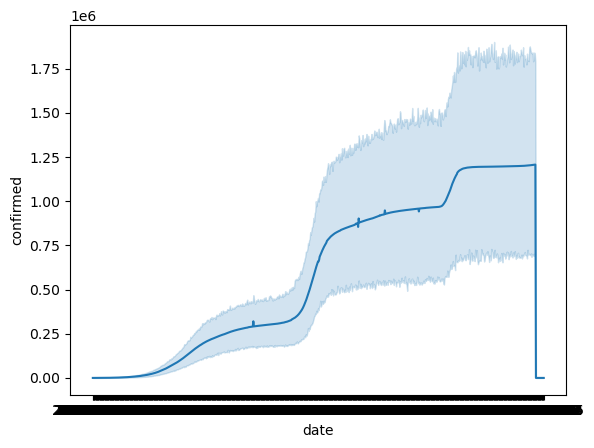

In [218]:
fig, ax = plt.subplots()
sns.lineplot(x='date',y='confirmed',data=df_covid, ax=ax)

In [220]:
df_covid_Mah = df_covid.loc[df_covid.region == "Maharashtra"]
df_covid_Mah.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 15857 to 16666
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       810 non-null    object
 1   region     810 non-null    object
 2   confirmed  810 non-null    int64 
 3   active     810 non-null    int64 
 4   cured      810 non-null    int64 
 5   deaths     810 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 44.3+ KB


<Axes: xlabel='date', ylabel='confirmed'>

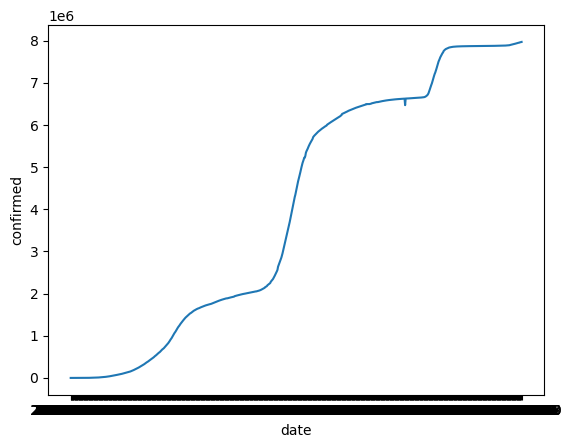

In [221]:
fig, ax = plt.subplots()
sns.lineplot(x='date',y='confirmed',data=df_covid_Mah, ax=ax)

y값을 로그 스케일 10의 1승, 2승, 3승...<br>
로그형식으로 변환해서 그립니다.

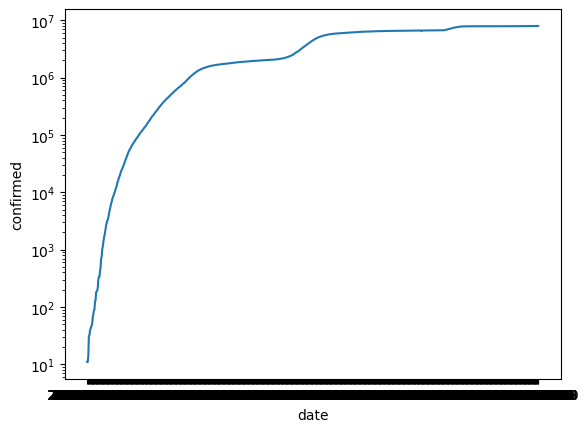

In [222]:
fig, ax = plt.subplots()
sns.lineplot(x='date',y='confirmed',data=df_covid_Mah, ax=ax)
ax.set_yscale('log')

In [224]:
#plotly에서 로그스케일
fig = px.line(
    df_covid_Mah, x='date', y='confirmed', width=400,height=400,log_y=True
)
fig.show()

# 색깔 선택하기

In [ ]:
#seaborn color pallette, plotly color

<Axes: xlabel='total_bill', ylabel='tip'>

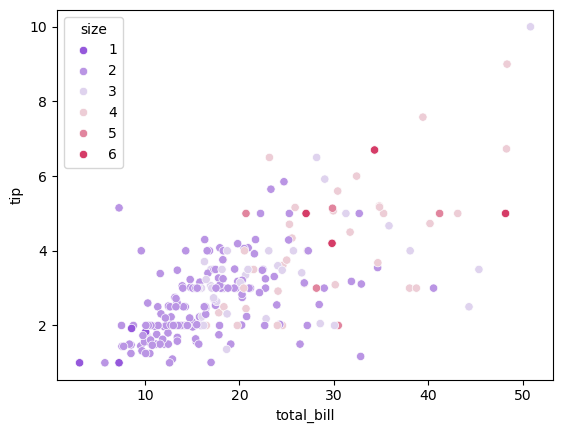

In [236]:
df_tips = sns.load_dataset('tips')
# color = sns.color_palette('light:#7fff00', as_cmap=True)
# color = sns.color_palette('coolwarm', as_cmap=True)
color = sns.diverging_palette(1000,1, as_cmap=True)

fig, ax = plt.subplots()
sns.scatterplot(
    x='total_bill', y='tip', data=df_tips, ax=ax,
    hue='size', palette=color
)